In [413]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

In [414]:
class NNregression:
  def GELU(self, x):
    return 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) *(x + 0.044715 * x**3)))
  def dGELU(self, x):
    tanh_term = np.tanh(np.sqrt(2/np.pi)*(x+0.044715*x**3))
    left = 0.5*(1+tanh_term)
    right = (0.5*x*(1-tanh_term**2)*np.sqrt(2/np.pi)*(1+3*0.044715*x**2))
    return left + right
  def r2_score(self,y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)
  def predict(self,Xpredict):
    factivlayers = [Xpredict]
    fneuronlayers = []
    for i in range(len(self.nnarchitecture)-2):
      fneuronlayers.append(np.dot(factivlayers[i],self.weights[i]) + self.bias[i])
      factivlayers.append(self.GELU(fneuronlayers[-1]))
    fneuronlayers.append(np.dot(factivlayers[-1],self.weights[-1]) + self.bias[-1])
    fYpredicted = fneuronlayers[-1]
    return fYpredicted,fneuronlayers,factivlayers
  def targetpredict(self,Xpredict):
    return self.predict(Xpredict)[0]
  def functionLoss(self,Ypredicted,Ytrue):
    return np.mean((Ypredicted - Ytrue)**2)
  def RMSELoss(self,Ypredicted,Ytrue):
    return np.sqrt(np.mean((Ypredicted - Ytrue)**2))
  def fit(self,Xtrain,Ytrain,Xval,Yval,lrate=0.1,epoch = 5000,batchsize = 32,seed=42):
    #init
    #hidencount = np.random.randint((len(self.classes)+Xtrain.shape[1])//2, Xtrain.shape[1])
    rng = np.random.default_rng(seed)
    #random architecture
    #self.nnarchitecture = np.concatenate(([Xtrain.shape[1]], np.random.randint(len(self.classes), Xtrain.shape[1]+1, hidencount),[len(self.classes)]))
    self.nnarchitecture = np.array([Xtrain.shape[1],8,4,2,1])
    print("NN archutecture ::",self.nnarchitecture)
    self.weights = []
    self.bias = []
    self.TrainLoss = []
    self.ValLoss = []
    for i in range(1,len(self.nnarchitecture)):
      n,m = self.nnarchitecture[i-1],self.nnarchitecture[i],
      wmatrix = rng.normal(0,np.sqrt(2/n),size=(n,m))
      #wmatrix = rng.uniform(-0.5,0.5,size=(n, m))
      bvector = rng.uniform(-0.5,0.5,size=m)
      self.weights.append(wmatrix)
      self.bias.append(bvector)
    objcount = Xtrain.shape[0]
    #train
    oldloss = np.inf
    for iter in range(epoch):
      #forward
      indices = rng.choice(Xtrain.shape[0], size=batchsize, replace=False)
      Xbatch = Xtrain[indices]
      Ybatch = Ytrain[indices]
      Ypredicted,neuronlayers,activlayers = self.predict(Xbatch)
      Loss = self.functionLoss(Ypredicted,Ybatch)
      if iter%50 == 0:
        targettrain = self.targetpredict(Xtrain)
        targetval = self.targetpredict(Xval)
        self.TrainLoss.append(self.functionLoss(targettrain,Ytrain))
        self.ValLoss.append(self.functionLoss(targetval,Yval))
      if abs(Loss-oldloss)<1e-6:
        print("Best iteration ::",iter)
        break
      oldloss = Loss
      #back
      oldweights = copy.deepcopy(self.weights)
      oldbias = copy.deepcopy(self.bias)
      localgradient = 2*(Ypredicted - Ybatch)/batchsize
      self.weights[-1] = oldweights[-1] - lrate*np.dot(activlayers[-1].T,localgradient)
      self.bias[-1] = oldbias[-1] - lrate*np.sum(localgradient,axis=0)
      for i in range(-2,-len(self.weights)-1,-1):
        localgradient = (localgradient @ (oldweights[i+1]).T)*self.dGELU(neuronlayers[i])
        self.weights[i] = oldweights[i] - lrate*np.dot(activlayers[i].T,localgradient)
        self.bias[i] = oldbias[i] - lrate*np.sum(localgradient,axis=0)
      del neuronlayers,activlayers,localgradient,oldweights,oldbias
      lrate = lrate * 0.999
    print("Model Trained")
    print("Last batch Loss ::",Loss)

In [415]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = ""
df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,"yasserh/housing-prices-dataset","Housing.csv")

/tmp/ipykernel_1068/1490287725.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,"yasserh/housing-prices-dataset","Housing.csv")


Using Colab cache for faster access to the 'housing-prices-dataset' dataset.


In [416]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [417]:
df = df.dropna()
df = df.drop_duplicates()

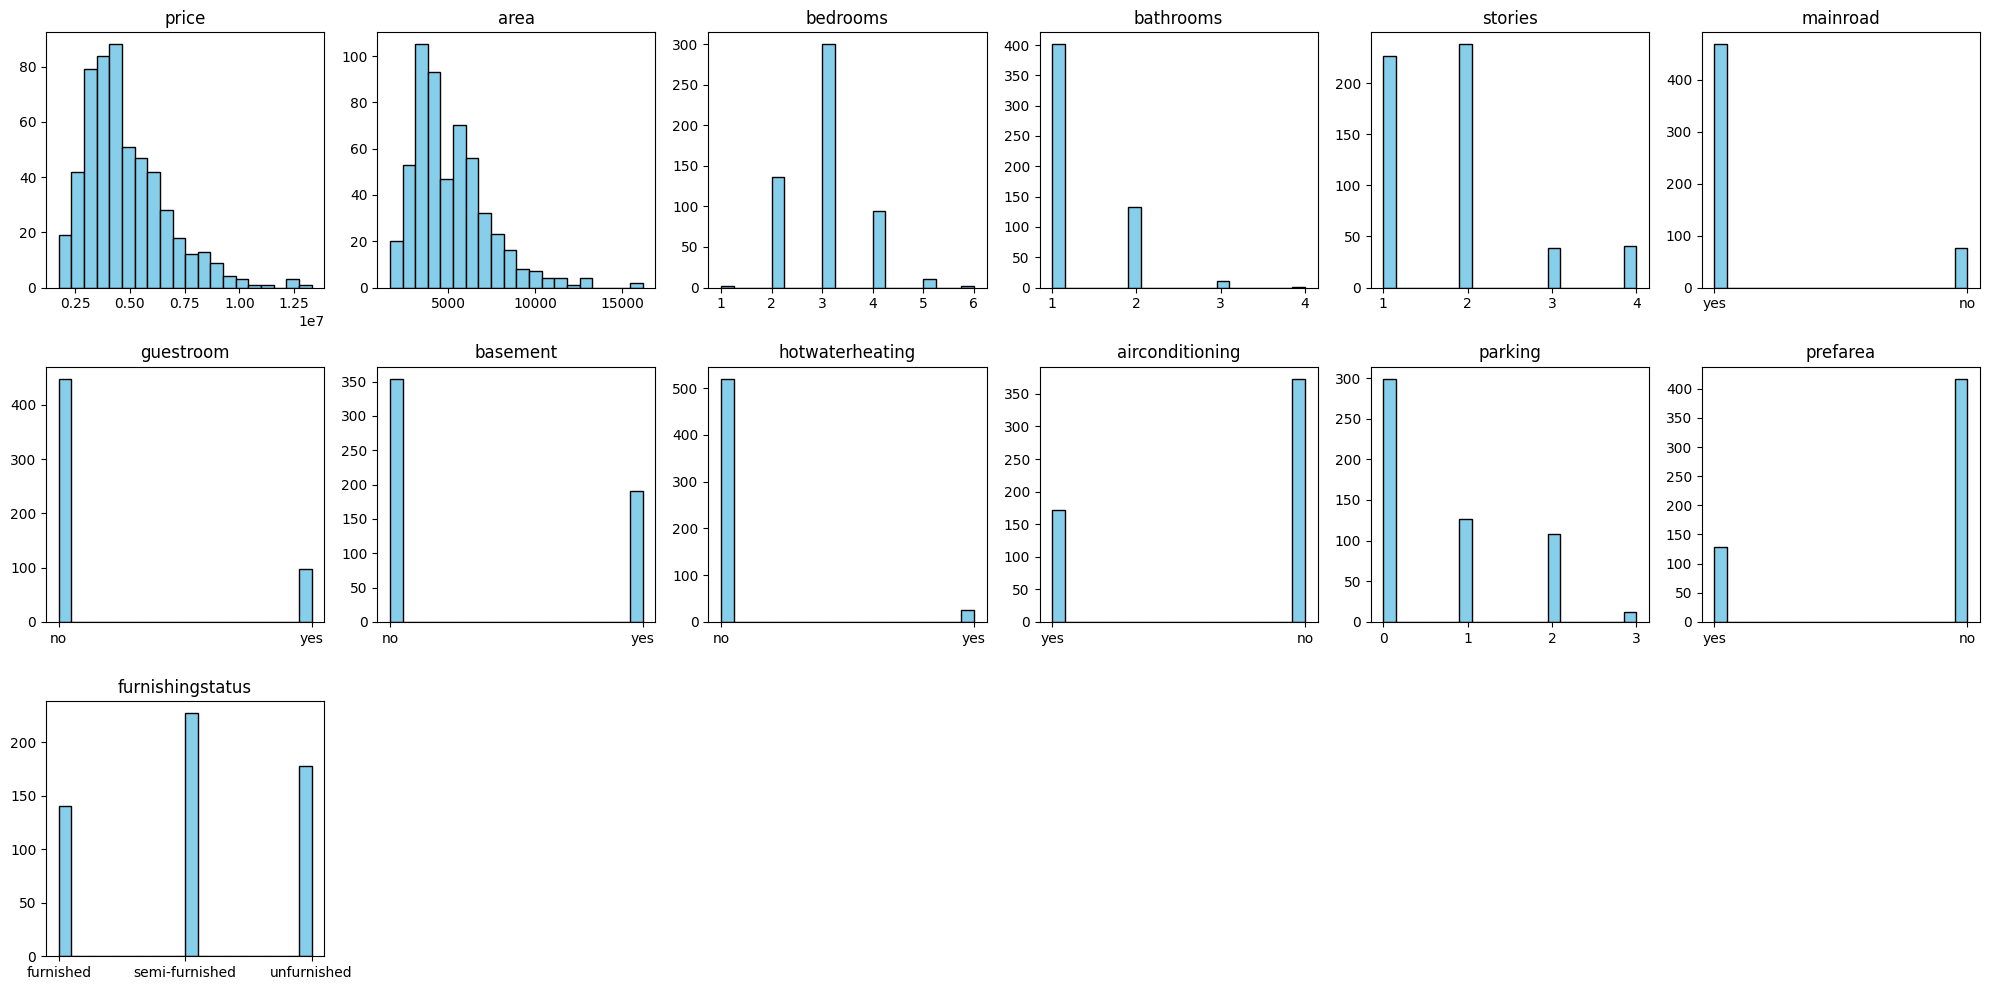

In [418]:
fig, axes = plt.subplots(3,6,figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
  axes[i].hist(df[col], bins=20, color='skyblue', edgecolor='black')
  axes[i].set_title(col)

for j in range(i + 1, len(axes)):
  axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [419]:
cat_columns = df.select_dtypes(include="object").columns
for col in cat_columns:
  print(col, ":", df[col].unique())

mainroad : ['yes' 'no']
guestroom : ['no' 'yes']
basement : ['no' 'yes']
hotwaterheating : ['no' 'yes']
airconditioning : ['yes' 'no']
prefarea : ['yes' 'no']
furnishingstatus : ['furnished' 'semi-furnished' 'unfurnished']


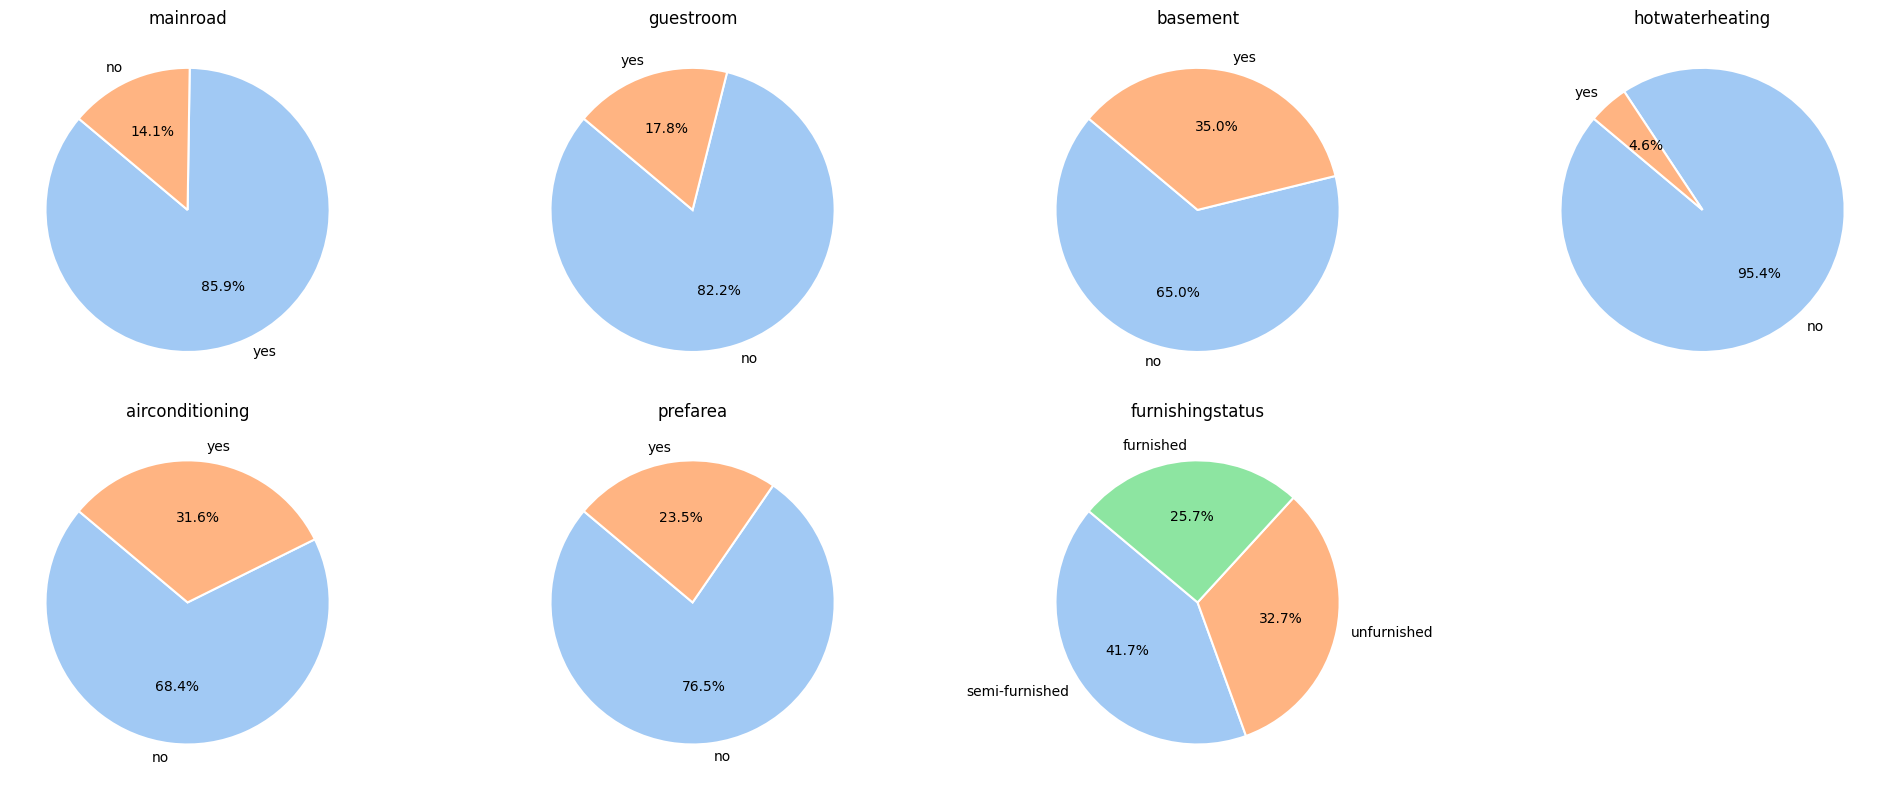

In [420]:
fig, axes = plt.subplots(2,4, figsize=(20, 8))
axes = axes.flatten()
palette = sns.color_palette("pastel")

for i, col in enumerate(cat_columns):
  data = df[col].value_counts()
  axes[i].pie(data, labels=data.index, autopct='%1.1f%%', startangle=140, colors=palette,wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
  axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

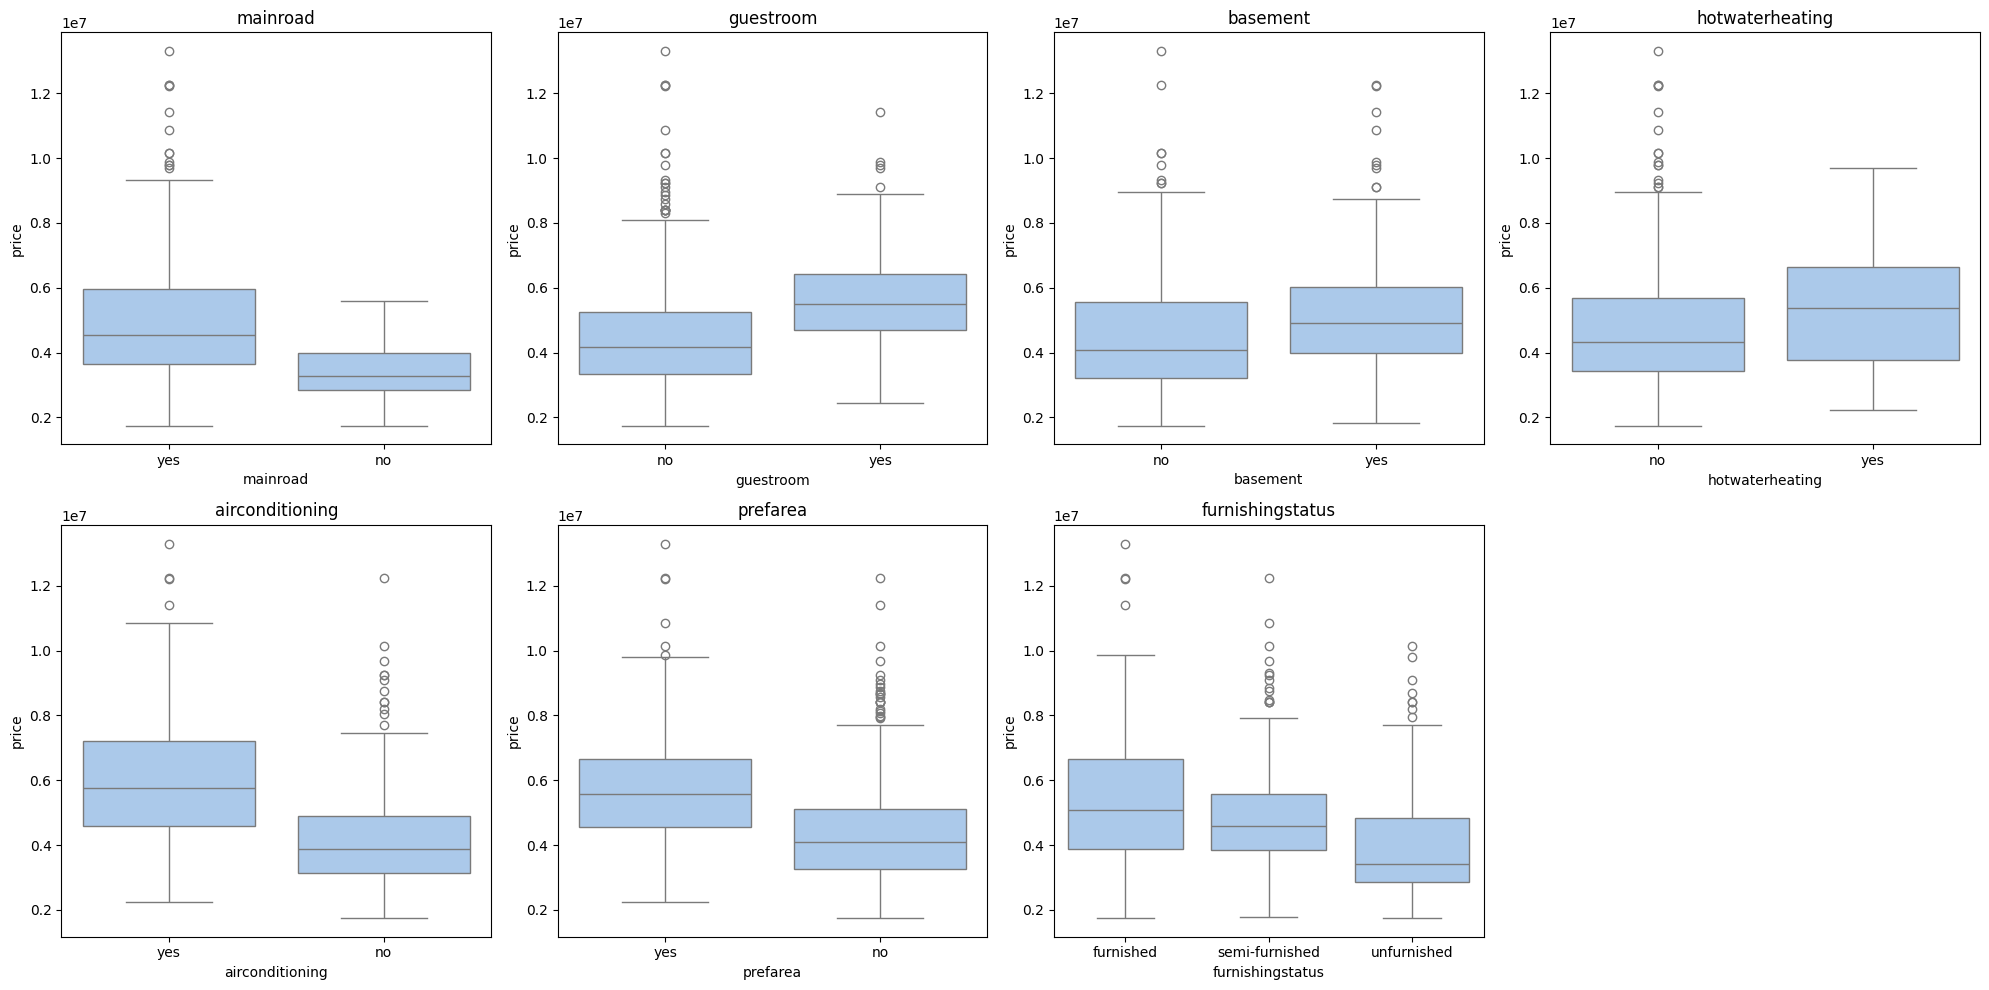

In [421]:

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(cat_columns):
  sns.boxplot(x = col, y="price",data=df,ax=axes[i])
  axes[i].set_title(col)
for j in range(i+1, len(axes)):
  axes[j].set_visible(False)
plt.tight_layout()
plt.show()

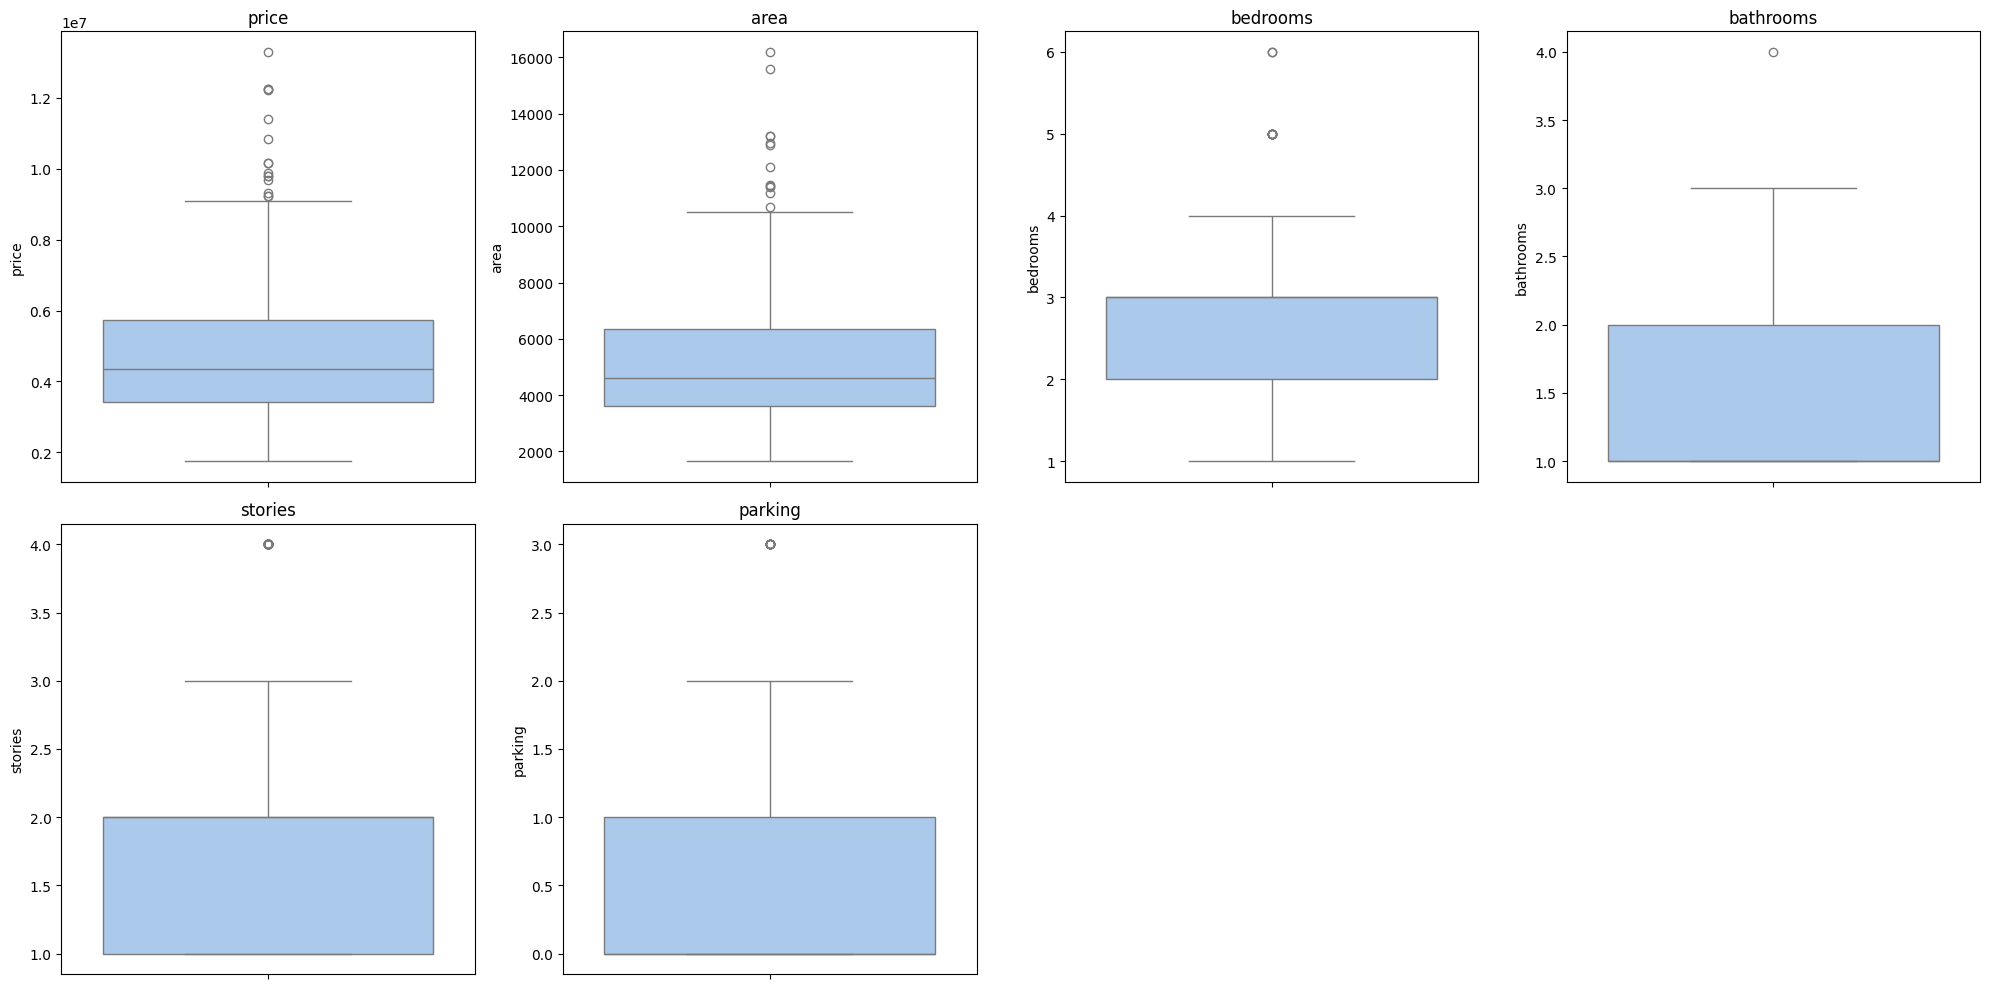

In [422]:
int_columns = df.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(int_columns):
  sns.boxplot(y=df[col], ax=axes[i])
  axes[i].set_title(col)
for j in range(i + 1, len(axes)):
  axes[j].set_visible(False)
plt.tight_layout()
plt.show()

In [423]:
outlier_columns = ['price', 'area','parking','bedrooms']
for col in outlier_columns:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [424]:
print(len(df))

496


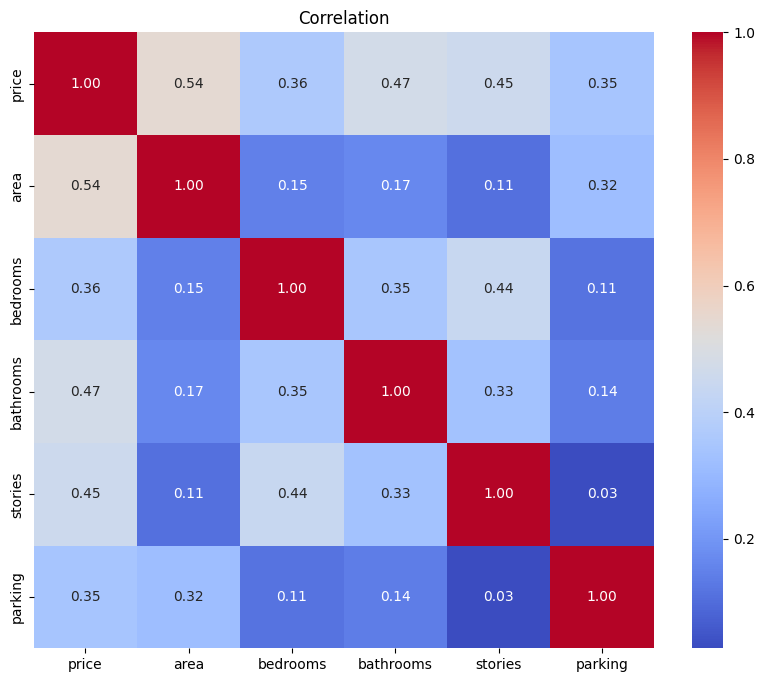

In [425]:
correlation = df.select_dtypes(include=("int64","float64")).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation')
plt.show()

In [426]:
df["total_rooms"] = df["bedrooms"] + df["bathrooms"]
df["rooms_density"] = df["bedrooms"] / df["area"]
df["area_per_room"] = df["area"] / df["bedrooms"]
df["area_squared"] = df["area"] ** 2

In [427]:
df = df.replace({'yes': 1, 'no': 0})
ohe = OneHotEncoder(drop='first', sparse_output=False)
furnished_encoded = ohe.fit_transform(df[['furnishingstatus']])
columns = ohe.get_feature_names_out(['furnishingstatus'])
df = pd.concat([df.drop('furnishingstatus', axis=1),pd.DataFrame(furnished_encoded, columns=columns, index=df.index)], axis=1)
df['area'] = np.log1p(df['area'])
df['price'] = np.log1p(df['price'])

/tmp/ipykernel_1068/1805414715.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'yes': 1, 'no': 0})


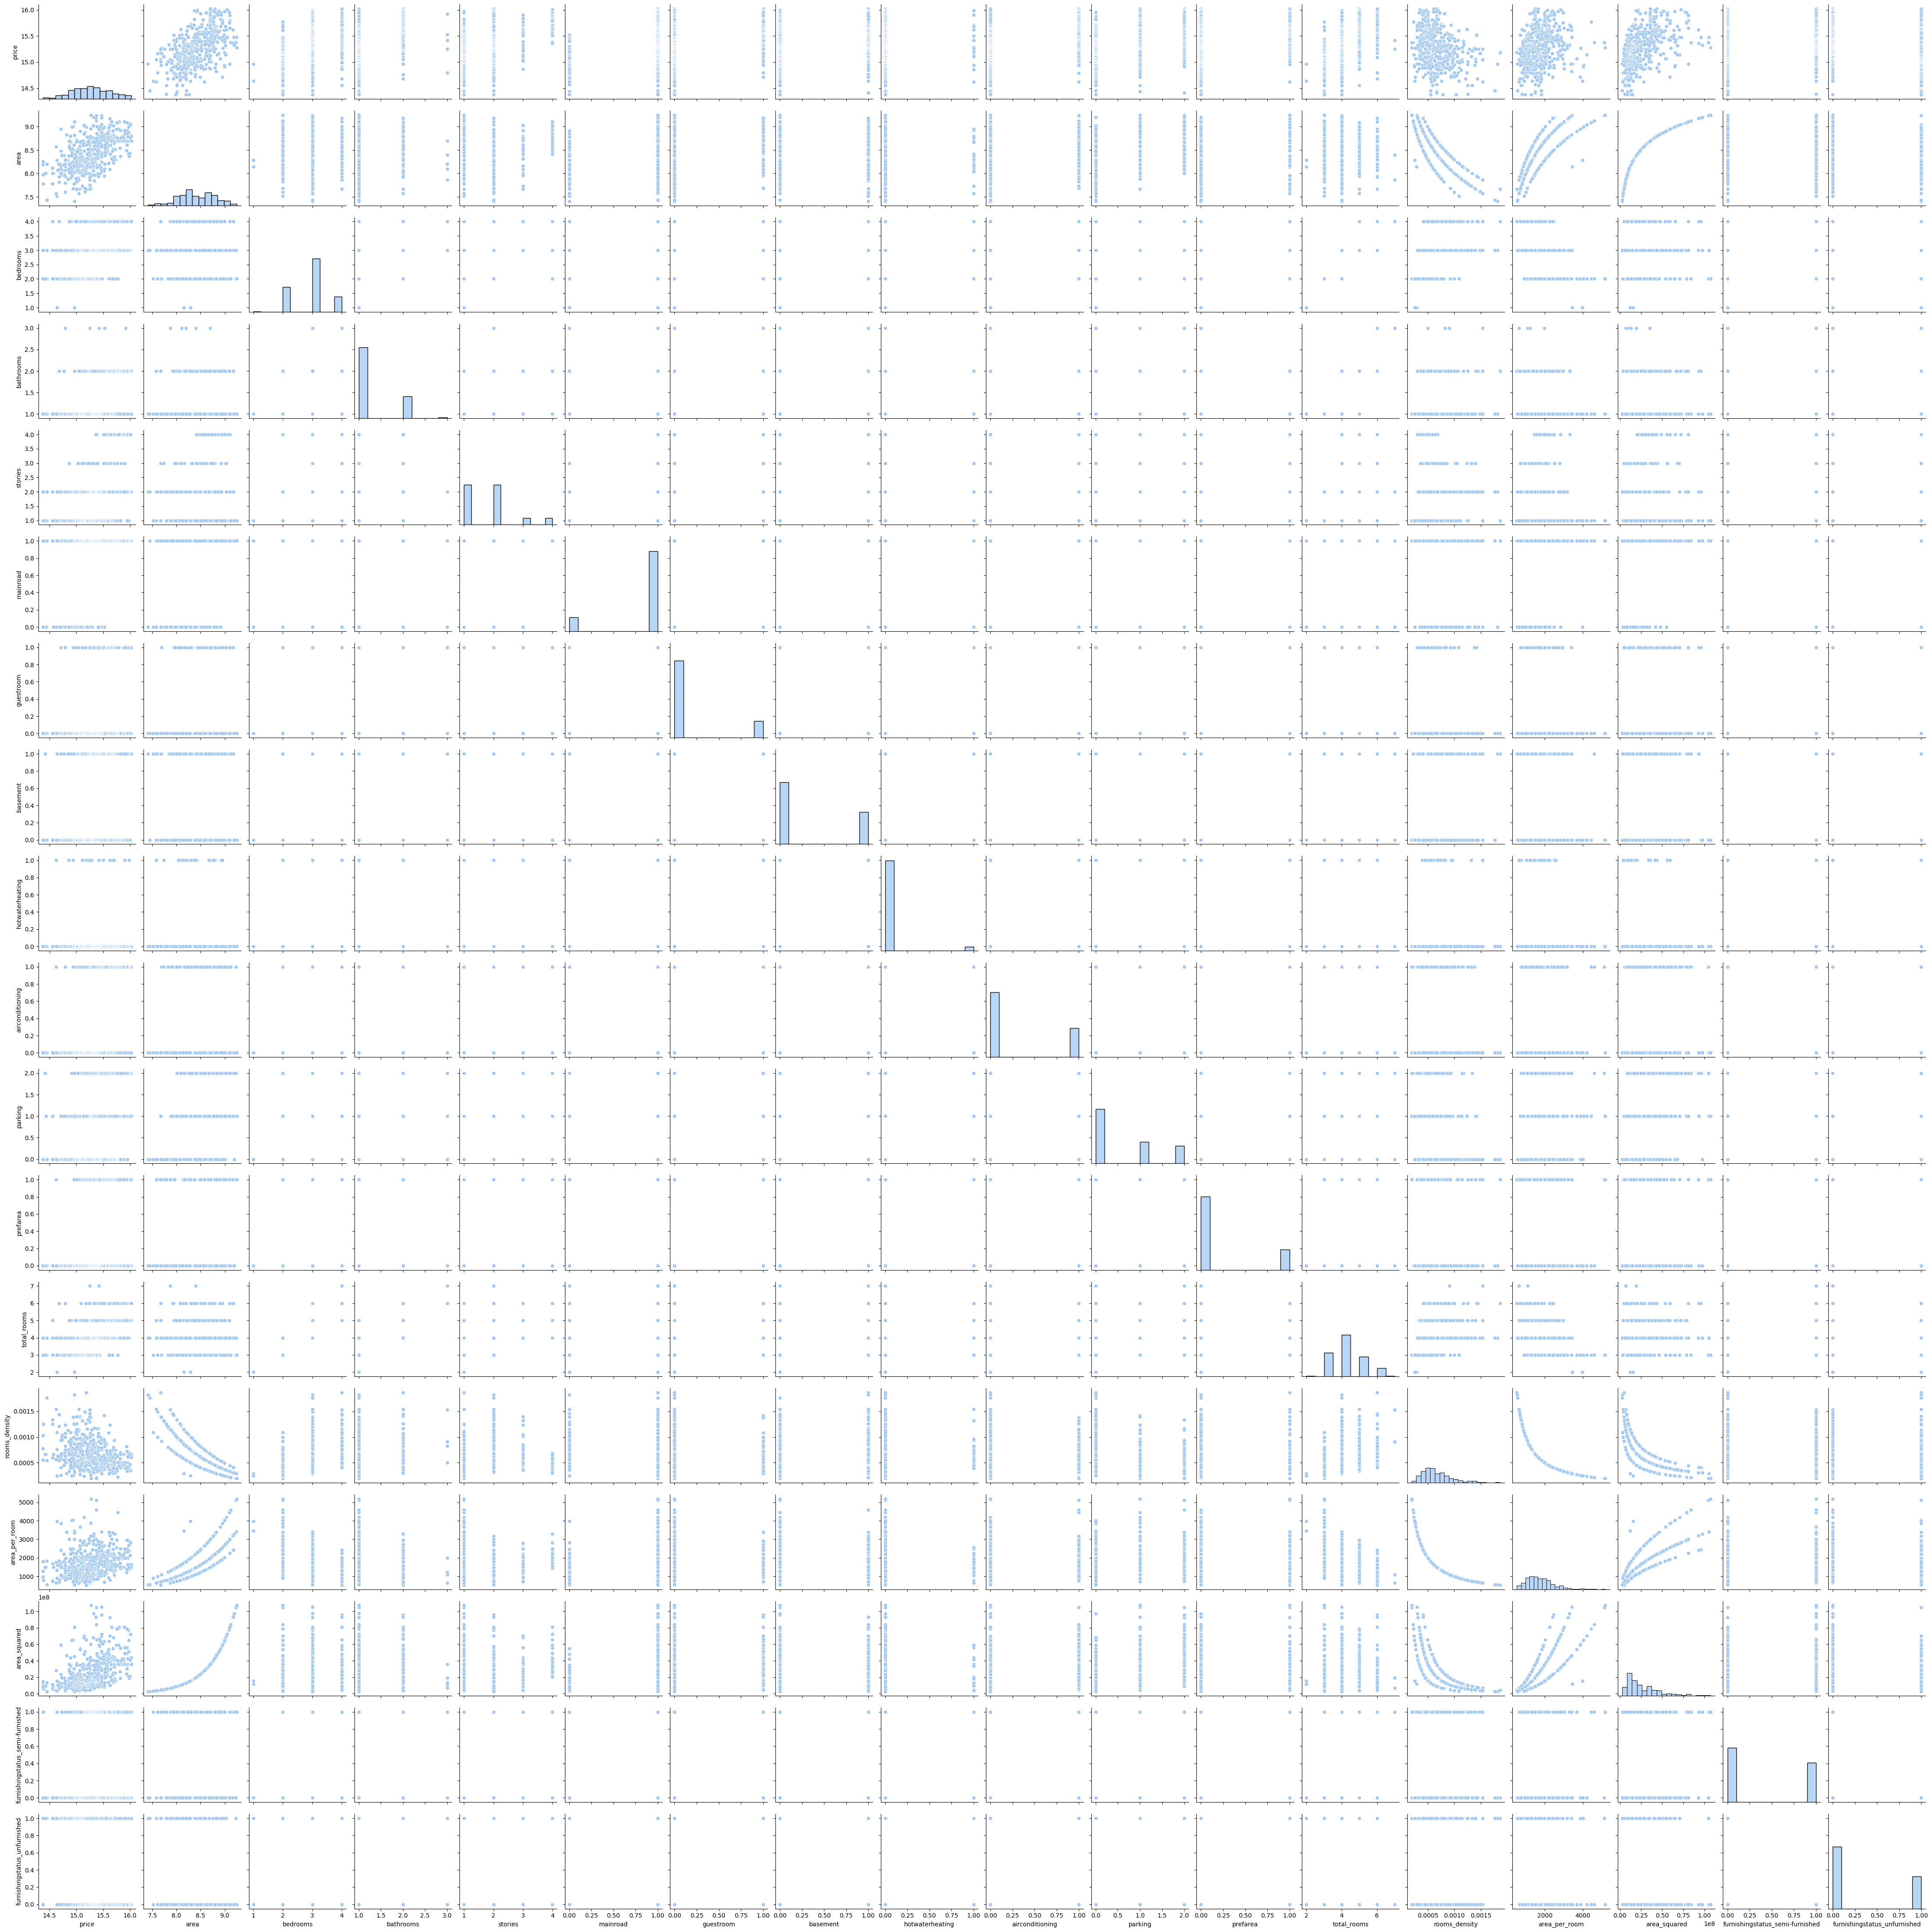

In [428]:
sns.pairplot(df)

In [429]:
X = df[['area', 'bathrooms', 'stories','basement', 'airconditioning','furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished',"total_rooms","rooms_density","area_per_room","area_squared"]]
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.25,random_state=42)
Xscaler = StandardScaler()
Yscaler = StandardScaler()
X_train = Xscaler.fit_transform(X_train)
X_test = Xscaler.transform(X_test)
X_val = Xscaler.transform(X_val)
y_train = Yscaler.fit_transform(y_train.values.reshape(-1, 1))
y_test = Yscaler.transform(y_test.values.reshape(-1, 1))
y_val = Yscaler.transform(y_val.values.reshape(-1, 1))

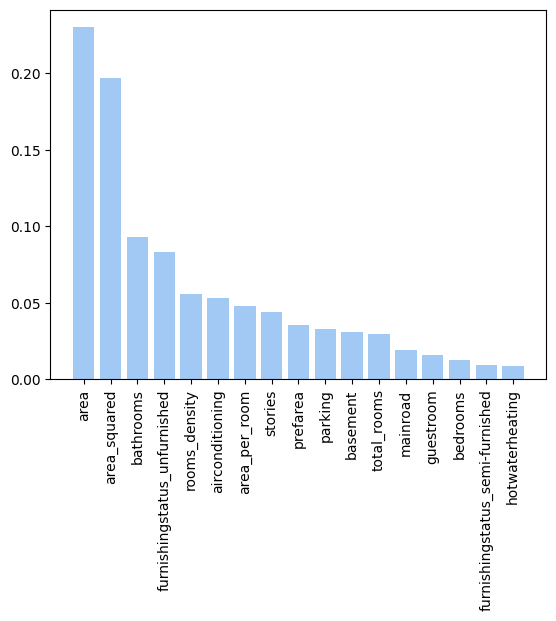

In [430]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(df.iloc[:, 1:],y)
importances = rf.feature_importances_
feature_names = df.iloc[:, 1:].columns
indices = np.argsort(importances)[::-1]
plt.bar(range(df.iloc[:, 1:].shape[1]), importances[indices])
plt.xticks(range(df.iloc[:, 1:].shape[1]), [feature_names[i] for i in indices], rotation=90)
plt.show()

In [431]:
regressor = NNregression()
regressor.fit(X_train,y_train,X_val,y_val,lrate=0.1,epoch = 10000,batchsize = 32,seed=77)
pred = regressor.targetpredict(X_test)
invpred = Yscaler.inverse_transform(pred)
real_ytest = Yscaler.inverse_transform(y_test)
r2 = regressor.r2_score(real_ytest,invpred)
print("Test R2 score ::",r2)

NN archutecture :: [11  8  4  2  1]
Model Trained
Last batch Loss :: 0.25712575152054423
Test R2 score :: 0.678194212363505


In [432]:
# k = 0
# max = 0
# for i in range(78,300):
#   real_ytest = Yscaler.inverse_transform(y_test)
#   regressor.fit(X_train,y_train,X_val,y_val,lrate=0.1,epoch = 6000,batchsize = 32,seed=i)
#   pred = regressor.targetpredict(X_test)
#   invpred = Yscaler.inverse_transform(pred)
#   r2 = regressor.r2_score(real_ytest,invpred)
#   print(i)
#   if r2 > max:
#     max = r2
#     k = i
#     print(k,"---------------------------------------------",r2)
#     if r2 > 0.68:
#       break
# print(max)

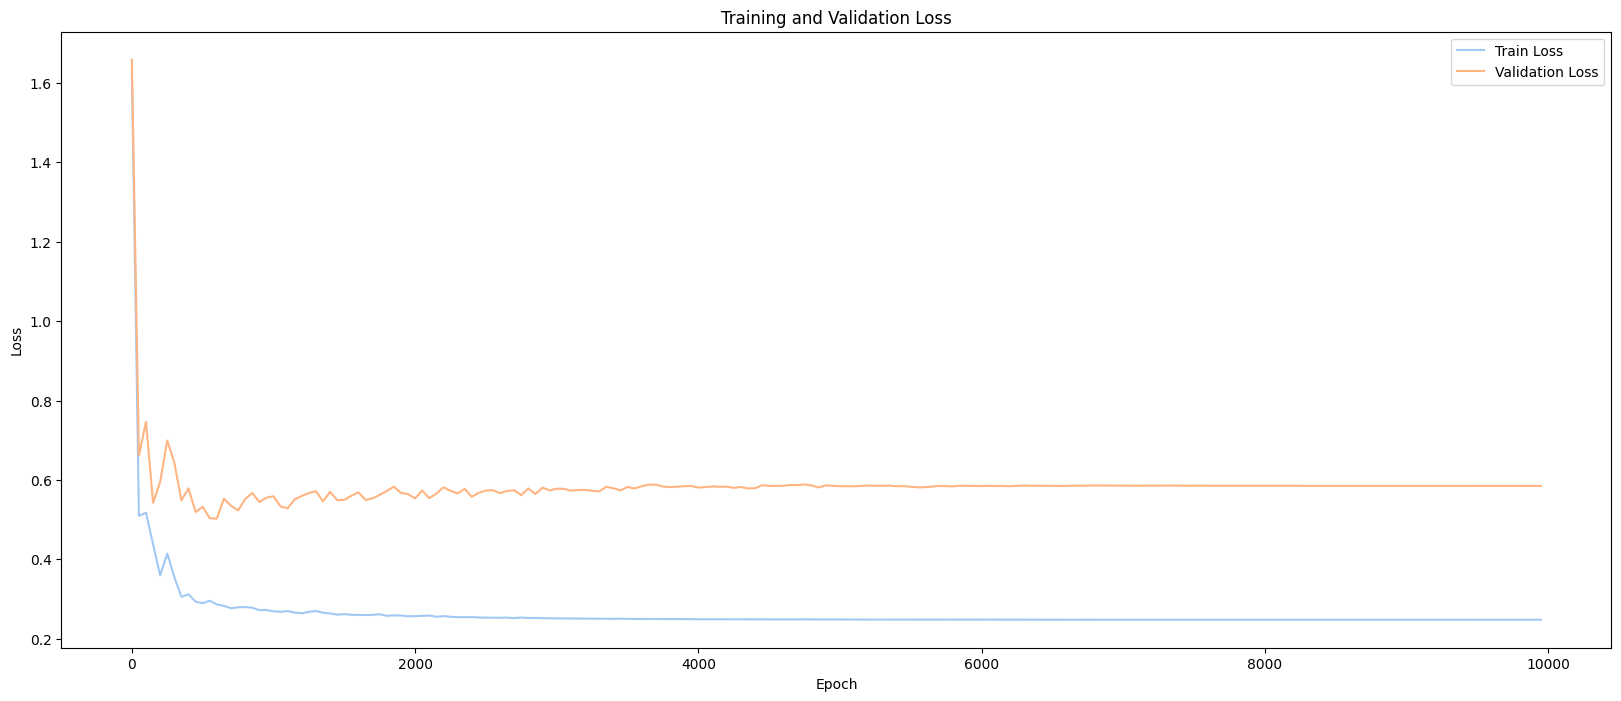

In [433]:
plt.figure(figsize=(20, 8))
epochrange = np.arange(0,10000,50)
plt.plot(epochrange, regressor.TrainLoss, label='Train Loss')
plt.plot(epochrange, regressor.ValLoss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [434]:
print("Train Loss ::",regressor.TrainLoss[-1])
print("Val Loss ::",regressor.ValLoss[-1])
print("Test Loss ::",regressor.functionLoss(regressor.targetpredict(X_test),y_test))
print("Train RMSE ::",regressor.RMSELoss(regressor.targetpredict(X_train),y_train))
print("Val RMSE ::",regressor.RMSELoss(regressor.targetpredict(X_val),y_val))
print("Test RMSE ::",regressor.RMSELoss(regressor.targetpredict(X_test),y_test))

Train Loss :: 0.24779772746636397
Val Loss :: 0.5848772749174146
Test Loss :: 0.4799368410657586
Train RMSE :: 0.4977927671344742
Val RMSE :: 0.7647608178928842
Test RMSE :: 0.692774740493444
